# Notebook 4 - Instalment Payments Exploratory Analysis

This notebook explores the instalment-payment dataset. It contains information about scheduled instalments and the payments made toward previous Home Credit loans.

The analysis checks the structure of the data, applicant coverage, missing values, repeated payment records, payment timing and payment amounts. It also examines whether late or incomplete payments are related to default.

## Import libraries


In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", 30)
pd.set_option("display.max_rows", 100)
sns.set_style("whitegrid")

BLUE = "#2E6DB4"
ORANGE = "#E67E22"

print("Libraries imported successfully.")


Libraries imported successfully.


## Set file paths


In [5]:
installments_path = "data/raw/installments_payments.csv"
application_path = "data/raw/application_train.csv"


## Load the data


In [7]:
installments = pd.read_csv(installments_path)
application_target = pd.read_csv(application_path, usecols=["SK_ID_CURR", "TARGET"])

print("Installment-payment rows:", installments.shape[0])
print("Columns:", installments.shape[1])
print("Labelled applicants:", len(application_target))
installments.head()


Installment-payment rows: 13605401
Columns: 8
Labelled applicants: 307511


,SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT
0,1054186,161674,1.0,6,-1180.0,-1187.0,6948.360,6948.360
1,1330831,151639,0.0,34,-2156.0,-2156.0,1716.525,1716.525
2,2085231,193053,2.0,1,-63.0,-63.0,25425.000,25425.000
3,2452527,199697,1.0,3,-2418.0,-2426.0,24350.130,24350.130
4,2714724,167756,1.0,2,-1383.0,-1366.0,2165.040,2160.585


This file is much larger than the application file, because one applicant can have several previous loans, each loan can have several scheduled instalments, and one instalment can have several payment entries. SK_ID_CURR identifies the applicant, and SK_ID_PREV identifies the previous loan.


## Structure and identifier checks


In [10]:
print("Exact duplicate rows:", installments.duplicated().sum())
print("Missing SK_ID_CURR:", installments["SK_ID_CURR"].isna().sum())
print("Missing SK_ID_PREV:", installments["SK_ID_PREV"].isna().sum())
print("Unique applicants in complete file:", installments["SK_ID_CURR"].nunique())
print("Unique previous loans:", installments["SK_ID_PREV"].nunique())
print()
print(installments.dtypes.astype(str).value_counts())


Exact duplicate rows: 0
Missing SK_ID_CURR: 0
Missing SK_ID_PREV: 0
Unique applicants in complete file: 339587
Unique previous loans: 997752

float64    5
int64      3
Name: count, dtype: int64


No duplicate rows or missing IDs were found. The number of payment records is much larger than the number of applicants or loans, because each loan can have several scheduled instalments, and some instalments have several payment entries.


## Instalment history coverage

Checking how many applicants in the application data have instalment-payment records.


In [13]:
labelled_applicant_ids = set(application_target["SK_ID_CURR"])
instalment_applicant_ids = set(installments["SK_ID_CURR"])

applicants_with_instalments = labelled_applicant_ids.intersection(instalment_applicant_ids)
applicants_without_instalments = labelled_applicant_ids.difference(instalment_applicant_ids)
other_instalment_applicants = instalment_applicant_ids.difference(labelled_applicant_ids)

coverage_percent = len(applicants_with_instalments) / len(labelled_applicant_ids) * 100

print("Labelled applicants with instalment history:", len(applicants_with_instalments))
print("Instalment-history coverage:", round(coverage_percent, 2), "%")
print("Labelled applicants without instalment history:", len(applicants_without_instalments))
print("Other applicants in the instalment file:", len(other_instalment_applicants))

Labelled applicants with instalment history: 291643
Instalment-history coverage: 94.84 %
Labelled applicants without instalment history: 15868
Other applicants in the instalment file: 47944


In [14]:
coverage_table = application_target.copy()
coverage_table["HAS_INSTALLMENT_HISTORY"] = coverage_table["SK_ID_CURR"].isin(instalment_applicant_ids)

coverage_default_summary = coverage_table.groupby("HAS_INSTALLMENT_HISTORY")["TARGET"].agg(["count", "mean"])
coverage_default_summary["default_rate_percent"] = coverage_default_summary["mean"] * 100
coverage_default_summary.drop(columns="mean").round(2)


,count,default_rate_percent
HAS_INSTALLMENT_HISTORY,,
False,15868,5.98
True,291643,8.19


Instalment-payment history is available for 94.84% of applicants. Applicants with this history have a slightly higher default rate, but that does not mean having payment records causes default. It could still be a useful signal.


## Missing-value analysis


In [17]:
missing_summary = pd.DataFrame({
    "missing_count": installments.isna().sum(),
    "missing_percent": (installments.isna().mean() * 100).round(4)
})
missing_summary = missing_summary[missing_summary["missing_count"] > 0]
missing_summary = missing_summary.sort_values("missing_percent", ascending=False)

print("Columns containing missing values:", len(missing_summary))
missing_summary


Columns containing missing values: 2


,missing_count,missing_percent
DAYS_ENTRY_PAYMENT,2905,0.0214
AMT_PAYMENT,2905,0.0214


These missing values will be kept as missing, since an unavailable payment date or amount might mean the payment was not properly recorded. No column needs to be removed because of missingness.


## Repeated instalment records and split payments


In [20]:
installment_key = ["SK_ID_PREV", "NUM_INSTALMENT_VERSION", "NUM_INSTALMENT_NUMBER"]
key_counts = installments.groupby(installment_key).size()
repeated_key_counts = key_counts[key_counts > 1]

print("Unique installment obligations:", len(key_counts))
print("Obligations appearing more than once:", len(repeated_key_counts))
print("Rows beyond the first occurrence:", int((repeated_key_counts - 1).sum()))
print("Largest number of payment rows for one obligation:", key_counts.max())
repeated_key_counts.describe().to_frame("payment_rows_per_obligation")


Unique installment obligations: 12951918
Obligations appearing more than once: 640905
Rows beyond the first occurrence: 653483
Largest number of payment rows for one obligation: 12


,payment_rows_per_obligation
count,640905.000000
mean,2.019625
std,0.151484
min,2.000000
25%,2.000000
50%,2.000000
75%,2.000000
max,12.000000


These repeated rows are not accidental duplicates. They likely represent payments made in several parts, so they will be kept and combined instead of removed.


### Examples of instalments with multiple payment entries


In [23]:
example_keys = repeated_key_counts.sort_values(ascending=False).head(5).reset_index()[installment_key]
example_rows = installments.merge(example_keys, on=installment_key, how="inner")
example_rows = example_rows.sort_values(installment_key + ["DAYS_ENTRY_PAYMENT"])
display(example_rows)

del example_keys, example_rows, key_counts, repeated_key_counts


,SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT
9,1030631,277041,2.0,101,-798.0,-740.0,1350.0,495.675
10,1030631,277041,2.0,101,-798.0,-696.0,1350.0,505.035
11,1030631,277041,2.0,101,-798.0,-676.0,1350.0,61.695
12,1030631,277041,2.0,101,-798.0,-649.0,1350.0,61.695
14,1030631,277041,2.0,101,-798.0,-608.0,1350.0,2.115
8,1030631,277041,2.0,101,-798.0,-574.0,1350.0,2.115
13,1030631,277041,2.0,101,-798.0,-550.0,1350.0,2.115
15,1030631,277041,2.0,101,-798.0,-434.0,1350.0,219.555
17,1240132,366695,2.0,101,-990.0,-979.0,1350.0,81.720
16,1240132,366695,2.0,101,-990.0,-957.0,1350.0,25.920


The same scheduled instalment can have several payment rows. The payment amounts need to be added together before deciding if the instalment was fully paid, so these rows will be combined rather than removed as duplicates.


## Combine payment entries into instalment obligations


In [26]:
obligations = installments.groupby(
    ["SK_ID_CURR"] + installment_key,
    as_index=False
).agg(
    DAYS_INSTALMENT=("DAYS_INSTALMENT", "max"),
    DAYS_ENTRY_PAYMENT=("DAYS_ENTRY_PAYMENT", "max"),
    AMT_INSTALMENT=("AMT_INSTALMENT", "max"),
    AMT_PAYMENT=("AMT_PAYMENT", lambda values: values.sum(min_count=1)),
    PAYMENT_ROW_COUNT=("SK_ID_CURR", "size"),
)

print("Raw payment rows:", len(installments))
print("Installment obligations after combining split payments:", len(obligations))
obligations.head()


Raw payment rows: 13605401
Installment obligations after combining split payments: 12951918


,SK_ID_CURR,SK_ID_PREV,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT,PAYMENT_ROW_COUNT
0,100001,1369693,1.0,1,-1709.0,-1715.0,3951.00,3951.00,1
1,100001,1369693,1.0,2,-1679.0,-1715.0,3951.00,3951.00,1
2,100001,1369693,1.0,3,-1649.0,-1660.0,3951.00,3951.00,1
3,100001,1369693,2.0,4,-1619.0,-1628.0,17397.90,17397.90,1
4,100001,1851984,1.0,2,-2916.0,-2916.0,3982.05,3982.05,1


Each obligation now has one row. The scheduled amount is kept, the separate payments are added together, and the latest payment date is used. This gives a more accurate way to measure late payments, underpayments, and overpayments.


## Payment timing and amount features


In [29]:
obligations["PAYMENT_DELAY_DAYS"] = obligations["DAYS_ENTRY_PAYMENT"] - obligations["DAYS_INSTALMENT"]
obligations["DAYS_LATE"] = obligations["PAYMENT_DELAY_DAYS"].clip(lower=0)
obligations["DAYS_EARLY"] = (-obligations["PAYMENT_DELAY_DAYS"]).clip(lower=0)
obligations["PAYMENT_SHORTFALL"] = (obligations["AMT_INSTALMENT"] - obligations["AMT_PAYMENT"]).clip(lower=0)
obligations["PAYMENT_EXCESS"] = (obligations["AMT_PAYMENT"] - obligations["AMT_INSTALMENT"]).clip(lower=0)
obligations.loc[obligations["PAYMENT_SHORTFALL"] <= 0.01, "PAYMENT_SHORTFALL"] = 0
obligations["IS_LATE"] = np.where(obligations["DAYS_ENTRY_PAYMENT"].notna(),(obligations["DAYS_LATE"] > 0).astype(int), np.nan,)
obligations["IS_UNDERPAID"] = np.where(obligations["AMT_PAYMENT"].notna(),(obligations["PAYMENT_SHORTFALL"] > 0.01).astype(int), np.nan,)
obligations["IS_OVERPAID"] = np.where(obligations["AMT_PAYMENT"].notna(),(obligations["PAYMENT_EXCESS"] > 0.01).astype(int), np.nan,)

valid_amount = obligations["AMT_INSTALMENT"] > 0
obligations["PAYMENT_RATIO"] = np.nan
obligations.loc[valid_amount, "PAYMENT_RATIO"] = (obligations.loc[valid_amount, "AMT_PAYMENT"] / obligations.loc[valid_amount, "AMT_INSTALMENT"])

obligations[["PAYMENT_DELAY_DAYS", "DAYS_LATE", "PAYMENT_SHORTFALL", "PAYMENT_RATIO"]].describe(percentiles=[0.01, 0.50, 0.95, 0.99])


,PAYMENT_DELAY_DAYS,DAYS_LATE,PAYMENT_SHORTFALL,PAYMENT_RATIO
count,1.294901e+07,1.294901e+07,1.294901e+07,1.294879e+07
mean,-8.159773e+00,1.062554e+00,1.634483e+00,1.342861e+00
std,2.574210e+01,2.124942e+01,2.198056e+02,1.361625e+02
min,-3.189000e+03,0.000000e+00,0.000000e+00,2.759450e-06
1%,-6.100000e+01,0.000000e+00,0.000000e+00,1.000000e+00
50%,-5.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
95%,3.000000e+00,3.000000e+00,0.000000e+00,1.000000e+00
99%,1.900000e+01,1.900000e+01,0.000000e+00,1.361762e+00
max,2.884000e+03,2.884000e+03,1.288244e+05,1.942500e+05


In [30]:
payment_behaviour_summary = pd.Series({
    "obligations": len(obligations),
    "late_obligations": obligations["IS_LATE"].sum(),
    "late_percent": obligations["IS_LATE"].mean() * 100,
    "underpaid_obligations": obligations["IS_UNDERPAID"].sum(),
    "underpaid_percent": obligations["IS_UNDERPAID"].mean() * 100,
    "overpaid_obligations": obligations["IS_OVERPAID"].sum(),
    "overpaid_percent": obligations["IS_OVERPAID"].mean() * 100,
    "obligations_with_multiple_payment_rows": (obligations["PAYMENT_ROW_COUNT"] > 1).sum(),
    "missing_payment_date": obligations["DAYS_ENTRY_PAYMENT"].isna().sum(),
    "missing_payment_amount": obligations["AMT_PAYMENT"].isna().sum(),
})

payment_behaviour_summary.to_frame("value").round(2)

,value
obligations,12951918.00
late_obligations,1103475.00
late_percent,8.52
underpaid_obligations,2934.00
underpaid_percent,0.02
overpaid_obligations,179407.00
overpaid_percent,1.39
obligations_with_multiple_payment_rows,640905.00
missing_payment_date,2905.00
missing_payment_amount,2905.00


Most obligations were paid on time and in full. A few have a very large payment ratio, which can happen when the scheduled amount is very small, so these should not be assumed to be errors.


## Domain and unusual-value checks


In [33]:
domain_checks = pd.DataFrame({
    "check": [
        "DAYS_INSTALMENT is positive",
        "DAYS_ENTRY_PAYMENT is positive",
        "AMT_INSTALMENT is negative",
        "AMT_PAYMENT is negative",
        "AMT_INSTALMENT is zero",
        "AMT_PAYMENT is zero",
        "NUM_INSTALMENT_VERSION is negative",
        "NUM_INSTALMENT_NUMBER is negative"
    ],
    "rows_affected": [
        (installments["DAYS_INSTALMENT"] > 0).sum(),
        (installments["DAYS_ENTRY_PAYMENT"] > 0).sum(),
        (installments["AMT_INSTALMENT"] < 0).sum(),
        (installments["AMT_PAYMENT"] < 0).sum(),
        (installments["AMT_INSTALMENT"] == 0).sum(),
        (installments["AMT_PAYMENT"] == 0).sum(),
        (installments["NUM_INSTALMENT_VERSION"] < 0).sum(),
        (installments["NUM_INSTALMENT_NUMBER"] < 0).sum(),
    ]
})
domain_checks


,check,rows_affected
0,DAYS_INSTALMENT is positive,0
1,DAYS_ENTRY_PAYMENT is positive,0
2,AMT_INSTALMENT is negative,0
3,AMT_PAYMENT is negative,0
4,AMT_INSTALMENT is zero,290
5,AMT_PAYMENT is zero,1440
6,NUM_INSTALMENT_VERSION is negative,0
7,NUM_INSTALMENT_NUMBER is negative,0


Nothing major was found. The zero-amount records are uncommon, but they will be kept and flagged during cleaning instead of being removed.


## Distribution of payment behaviour


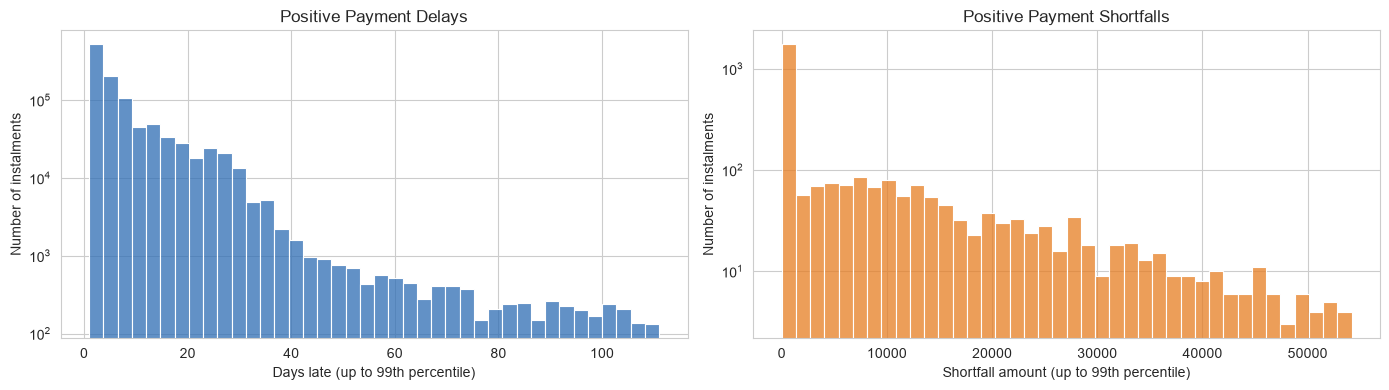

In [36]:
positive_late = obligations.loc[obligations["DAYS_LATE"] > 0, "DAYS_LATE"]
positive_shortfall = obligations.loc[obligations["PAYMENT_SHORTFALL"] > 0.01, "PAYMENT_SHORTFALL"]

late_limit = positive_late.quantile(0.99)
shortfall_limit = positive_shortfall.quantile(0.99)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(positive_late[positive_late <= late_limit], bins=40, ax=axes[0], color=BLUE)
sns.histplot(positive_shortfall[positive_shortfall <= shortfall_limit], bins=40, ax=axes[1], color=ORANGE)

axes[0].set_title("Positive Payment Delays")
axes[0].set_xlabel("Days late (up to 99th percentile)")
axes[0].set_ylabel("Number of instalments")

axes[1].set_title("Positive Payment Shortfalls")
axes[1].set_xlabel("Shortfall amount (up to 99th percentile)")
axes[1].set_ylabel("Number of instalments")

axes[0].set_yscale("log")
axes[1].set_yscale("log")

plt.tight_layout()
plt.show()


Most late payments and shortfalls are small, with a few much larger ones. The charts are capped at the 99th percentile to make the common pattern easier to see. The full range of values still stays in the data.


## Applicant-level target comparison

Each applicant can have many instalment obligations, so a few quick applicant-level summaries are created just for this comparison. These are not the final features.


In [39]:
obligations_labelled = obligations[obligations["SK_ID_CURR"].isin(labelled_applicant_ids)].copy()

applicant_installments = obligations_labelled.groupby("SK_ID_CURR").agg(
    INSTALLMENT_OBLIGATION_COUNT=("SK_ID_PREV", "count"),
    LATE_PAYMENT_COUNT=("IS_LATE", "sum"),
    LATE_PAYMENT_RATE=("IS_LATE", "mean"),
    AVERAGE_DAYS_LATE=("DAYS_LATE", "mean"),
    MAX_DAYS_LATE=("DAYS_LATE", "max"),
    UNDERPAYMENT_COUNT=("IS_UNDERPAID", "sum"),
    UNDERPAYMENT_RATE=("IS_UNDERPAID", "mean"),
    TOTAL_PAYMENT_SHORTFALL=("PAYMENT_SHORTFALL", "sum"),
    MEDIAN_PAYMENT_RATIO=("PAYMENT_RATIO", "median"),
).reset_index()

applicant_installments.head()

,SK_ID_CURR,INSTALLMENT_OBLIGATION_COUNT,LATE_PAYMENT_COUNT,LATE_PAYMENT_RATE,AVERAGE_DAYS_LATE,MAX_DAYS_LATE,UNDERPAYMENT_COUNT,UNDERPAYMENT_RATE,TOTAL_PAYMENT_SHORTFALL,MEDIAN_PAYMENT_RATIO
0,100002,19,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,25,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,1.0
2,100004,3,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,1.0
3,100006,16,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,1.0
4,100007,63,16.0,0.253968,1.0,12.0,0.0,0.0,0.0,1.0


In [40]:
applicant_installments_target = application_target.merge(applicant_installments, on="SK_ID_CURR", how="left")

feature_columns = [column for column in applicant_installments.columns if column != "SK_ID_CURR"]
feature_correlations = applicant_installments_target[feature_columns + ["TARGET"]].corr()["TARGET"].drop("TARGET")
feature_correlations.sort_values().to_frame("correlation_with_target").round(4)


,correlation_with_target
INSTALLMENT_OBLIGATION_COUNT,-0.0250
MEDIAN_PAYMENT_RATIO,-0.0119
MAX_DAYS_LATE,0.0038
AVERAGE_DAYS_LATE,0.0083
UNDERPAYMENT_RATE,0.0159
TOTAL_PAYMENT_SHORTFALL,0.0245
UNDERPAYMENT_COUNT,0.0283
LATE_PAYMENT_COUNT,0.0303
LATE_PAYMENT_RATE,0.0705


In [41]:
underpayment_count = applicant_installments_target["UNDERPAYMENT_COUNT"]
applicant_installments_target["UNDERPAYMENT_GROUP"] = np.select(
    [underpayment_count.isna(), underpayment_count > 0],
    ["No installment history", "Has underpayment"],
    default="No underpayment",
)
underpayment_default_summary = applicant_installments_target.groupby("UNDERPAYMENT_GROUP")["TARGET"].agg(["count", "mean"])
underpayment_default_summary["default_rate_percent"] = underpayment_default_summary["mean"] * 100
underpayment_default_summary.drop(columns="mean").round(2)


,count,default_rate_percent
UNDERPAYMENT_GROUP,,
Has underpayment,2488,15.68
No installment history,15868,5.98
No underpayment,289155,8.12


The late-payment rate has the strongest correlation with default among these summaries. The underpayment group is quite small, only 2,488 applicants, so that comparison should not be trusted too much.


## Main findings

The instalment-payment dataset contains multiple payment records for previous loans. Some scheduled instalments also have several payment entries, so these need to be combined before repayment behaviour can be measured properly.

The main findings are:

- Instalment history is available for 94.84% of labelled applicants.
- No exact duplicate rows or missing identifier values were found.
- Only two columns contain missing values, and their missing rates are very low.
- A total of 640,905 instalment obligations have multiple payment entries.
- Split payments should be combined rather than removed as duplicates.
- After consolidation, 8.52% of obligations were paid late.
- Underpayments were uncommon, while overpayments occurred more often.
- No negative payment amounts or future payment dates were found.
- Some zero scheduled amounts and zero payments were present.
- Applicants with underpayment history had a higher observed default rate.
- Late-payment rates, payment delays and payment shortfalls may provide useful applicant-level features.

Based on these findings, the cleaning stage will keep the repeated payment rows, keep the small amount of missing information, flag unusual payment records, and prepare the data for instalment-level feature engineering.
